In [1]:
from torch import optim

from Iris_utils import *
import sys
sys.path.append("../")
from optimizers.schedule_free_sgd import *
from optimizers.interpolated_schedule_free_sgd import *

In [2]:
# 全手法で共通のハイパーパラメータ
EPOCHS = 100
BATCH_SIZE = 16
NUM_SEED = 10
TEST_SIZE = 0.1
NUM_WORKERS = 10
VERBOSE = False

# 動作確認

In [3]:
train_dataloader, test_dataloader = load_data(batch_size = BATCH_SIZE,
                                              seed = 0,
                                              test_size = TEST_SIZE,
                                              num_workers = NUM_WORKERS)
inputs, teacher_signals = next(iter(train_dataloader))
print( inputs.shape, teacher_signals.shape, inputs[0] )

model = load_model(seed = 0)
print( model( torch.zeros(size = (1, 4)) ) )

torch.Size([16, 4]) torch.Size([16]) tensor([5.5000, 3.5000, 1.3000, 0.2000])
tensor([[-0.4777, -0.3311, -0.2061]], grad_fn=<AddmmBackward0>)


In [4]:
def run(target_dir, optimizer, search_space, fixed_params,
        epochs, batch_size, test_size, num_workers, num_seed, verbose = False):
    
    os.makedirs(target_dir, exist_ok = True)
    train_all(target_dir=target_dir,
              optimizer=optimizer,
              search_space=search_space,
              fixed_params=fixed_params,
              epochs=epochs,
              batch_size=batch_size,
              test_size=test_size,
              num_workers=num_workers,
              num_seed=num_seed,
              verbose=verbose)
    
    best_histories = get_best_histories(target_dir=target_dir,
                                        search_space=search_space,
                                        num_seed=num_seed,
                                        metric="test_acc",
                                        mode="max")

    plot_training_results(target_dir=target_dir,
                          best_histories=best_histories,
                          search_space=search_space,
                          metrics=["train_loss", "train_acc", "test_loss", "test_acc"])

    tmp = [
        [K, V["test_acc"][-1]] for K, V in best_histories.items()
    ]
    tmp = sorted(tmp, key=lambda x: x[1], reverse=True)
    for K, V in tmp:
        print(f"{K}: {V:.4f}")

# SGD

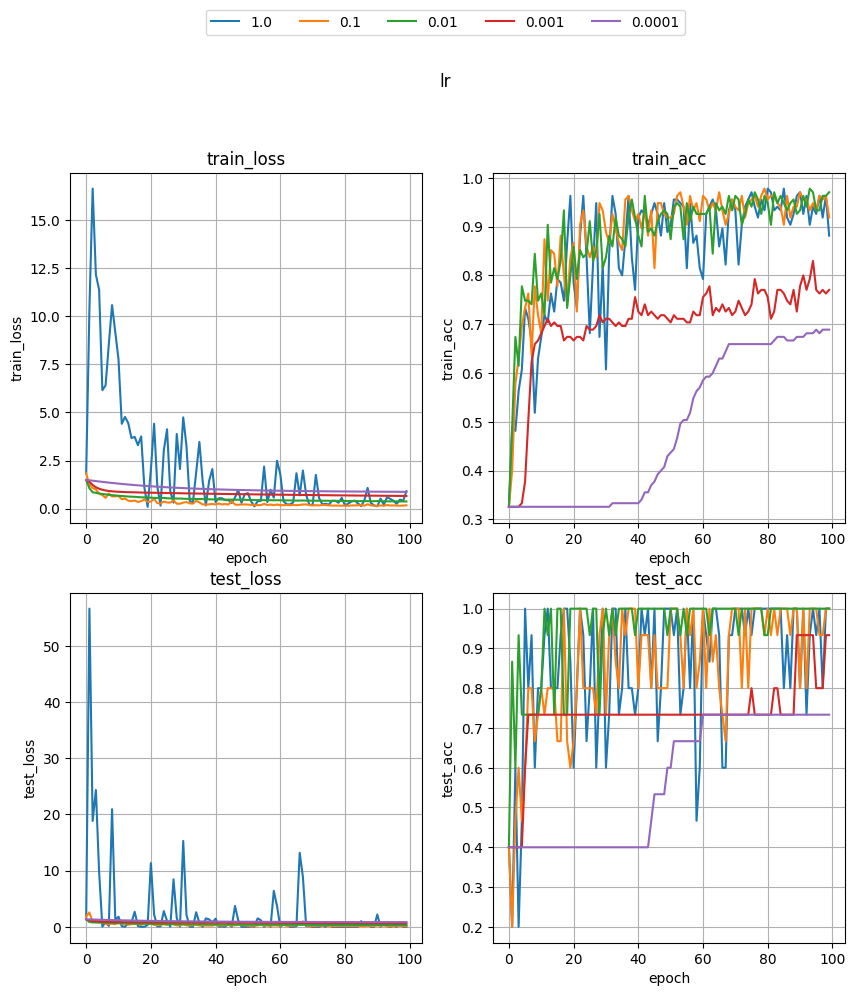

1.0: 1.0000
0.1: 1.0000
0.01: 1.0000
0.001: 0.9333
0.0001: 0.7333


In [5]:
OPTIMIZER = optim.SGD
TARGET_DIR = "results/SGD"

SEARCH_SPACE = {
    "lr": [1.0, 0.1, 0.01, 0.001, 0.0001],
}
FIXED_PARAMS ={
    "momentum": 0,
    "dampening": 0,
    "weight_decay": 0,
    "nesterov": False
}

run(target_dir=TARGET_DIR,
    optimizer=OPTIMIZER,
    search_space=SEARCH_SPACE,
    fixed_params=FIXED_PARAMS,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    test_size=TEST_SIZE,
    num_workers=NUM_WORKERS,
    num_seed=NUM_SEED,
    verbose=VERBOSE)

# Schedule Free SGD

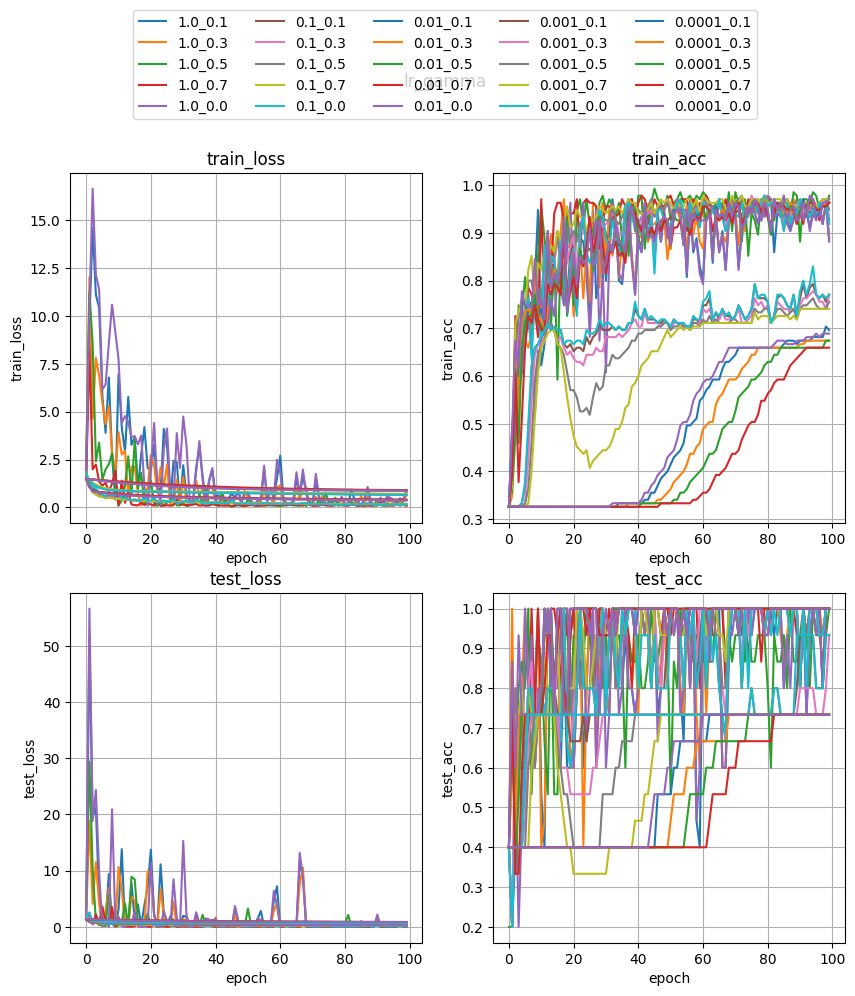

1.0_0.1: 1.0000
1.0_0.3: 1.0000
1.0_0.5: 1.0000
1.0_0.7: 1.0000
1.0_0.0: 1.0000
0.1_0.1: 1.0000
0.1_0.3: 1.0000
0.1_0.5: 1.0000
0.1_0.7: 1.0000
0.1_0.0: 1.0000
0.01_0.1: 1.0000
0.01_0.3: 1.0000
0.01_0.5: 1.0000
0.01_0.7: 1.0000
0.01_0.0: 1.0000
0.001_0.1: 0.9333
0.001_0.3: 0.9333
0.001_0.0: 0.9333
0.001_0.5: 0.7333
0.001_0.7: 0.7333
0.0001_0.1: 0.7333
0.0001_0.3: 0.7333
0.0001_0.5: 0.7333
0.0001_0.7: 0.7333
0.0001_0.0: 0.7333


In [6]:
OPTIMIZER = ScheduleFreeSGD
TARGET_DIR = "results/ScheduleFreeSGD"

SEARCH_SPACE = {
    "lr": [1.0, 0.1, 0.01, 0.001, 0.0001],
    "gamma": [0.1, 0.3, 0.5, 0.7, 0.0],
}
FIXED_PARAMS ={

}

run(target_dir=TARGET_DIR,
    optimizer=OPTIMIZER,
    search_space=SEARCH_SPACE,
    fixed_params=FIXED_PARAMS,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    test_size=TEST_SIZE,
    num_workers=NUM_WORKERS,
    num_seed=NUM_SEED,
    verbose=VERBOSE)

# Interpolated Schedule Free SGD

In [ ]:
OPTIMIZER = InterpolatedScheduleFreeSGD
TARGET_DIR = "results/InterpolatedScheduleFreeSGD"

SEARCH_SPACE = {
    "lr": [1.0, 0.1, 0.01, 0.001, 0.0001],
    "gamma": [0.1, 0.3, 0.5, 0.7, 0.0],
}
FIXED_PARAMS ={

}

run(target_dir=TARGET_DIR,
    optimizer=OPTIMIZER,
    search_space=SEARCH_SPACE,
    fixed_params=FIXED_PARAMS,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    test_size=TEST_SIZE,
    num_workers=NUM_WORKERS,
    num_seed=NUM_SEED,
    verbose=VERBOSE)

results/InterpolatedScheduleFreeSGD/1.0_0.1_0.json
results/InterpolatedScheduleFreeSGD/1.0_0.1_1.json
results/InterpolatedScheduleFreeSGD/1.0_0.1_2.json
results/InterpolatedScheduleFreeSGD/1.0_0.1_3.json
results/InterpolatedScheduleFreeSGD/1.0_0.1_4.json
results/InterpolatedScheduleFreeSGD/1.0_0.1_5.json
results/InterpolatedScheduleFreeSGD/1.0_0.1_6.json
results/InterpolatedScheduleFreeSGD/1.0_0.1_7.json


# AdamW

results/Adam/1.0_0.json
results/Adam/1.0_1.json
results/Adam/1.0_2.json
results/Adam/1.0_3.json
results/Adam/1.0_4.json
results/Adam/1.0_5.json
results/Adam/1.0_6.json
results/Adam/1.0_7.json
results/Adam/1.0_8.json
results/Adam/1.0_9.json
results/Adam/0.1_0.json
results/Adam/0.1_1.json
results/Adam/0.1_2.json
results/Adam/0.1_3.json
results/Adam/0.1_4.json
results/Adam/0.1_5.json
results/Adam/0.1_6.json
results/Adam/0.1_7.json
results/Adam/0.1_8.json
results/Adam/0.1_9.json
results/Adam/0.01_0.json
results/Adam/0.01_1.json
results/Adam/0.01_2.json
results/Adam/0.01_3.json
results/Adam/0.01_4.json
results/Adam/0.01_5.json
results/Adam/0.01_6.json
results/Adam/0.01_7.json
results/Adam/0.01_8.json
results/Adam/0.01_9.json
results/Adam/0.001_0.json
results/Adam/0.001_1.json
results/Adam/0.001_2.json
results/Adam/0.001_3.json
results/Adam/0.001_4.json
results/Adam/0.001_5.json
results/Adam/0.001_6.json
results/Adam/0.001_7.json
results/Adam/0.001_8.json
results/Adam/0.001_9.json
results/Ad

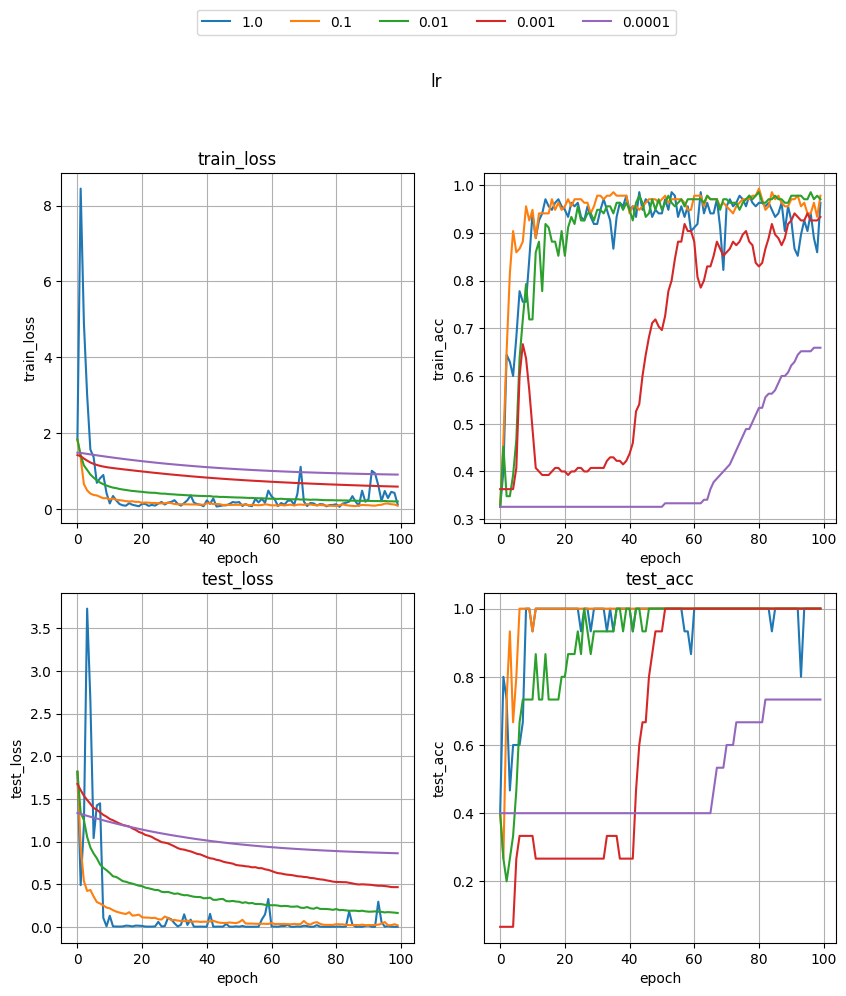

1.0: 1.0000
0.1: 1.0000
0.01: 1.0000
0.001: 1.0000
0.0001: 0.7333


In [ ]:
OPTIMIZER = optim.Adam
TARGET_DIR = "results/Adam"

SEARCH_SPACE = {
    "lr": [1.0, 0.1, 0.01, 0.001, 0.0001],
}
FIXED_PARAMS ={
    "betas": (0.9, 0.999),
    "eps": 1e-08,
    "weight_decay": 0,
    "amsgrad": False,
}

run(target_dir=TARGET_DIR,
    optimizer=OPTIMIZER,
    search_space=SEARCH_SPACE,
    fixed_params=FIXED_PARAMS,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    test_size=TEST_SIZE,
    num_workers=NUM_WORKERS,
    num_seed=NUM_SEED,
    verbose=VERBOSE)